In [1]:
import pandas as pd
import numpy as np
import urllib.request
import json

In [2]:
# 29.766066397309594, -95.78792027356833

In [5]:
url = 'https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/' + \
  '29.766066397309594,-95.78792027356833/2025-01-01/2025-02-01?unitGroup=metric&elements=datetime,temp,cloudcover' + \
  '&key=298LYYNTAZVEU5JN67C8W5AQE&contentType=json'
response = urllib.request.urlopen(url).read()

In [8]:
from dateutil import parser
data = json.loads(response)

In [10]:
lists = []
for data_point in data['days']:
    time = parser.parse(data_point['datetime'])
    temp_cloud = [time, data_point['temp'], data_point['cloudcover']]
    lists.append(temp_cloud)


In [14]:
df_temp_clouds = pd.DataFrame(lists, columns=['time', 'Temperature', 'Cloud cover'])
df_temp_clouds.set_index('time', inplace=True)

<Axes: title={'center': 'Weather data'}, xlabel='Time'>

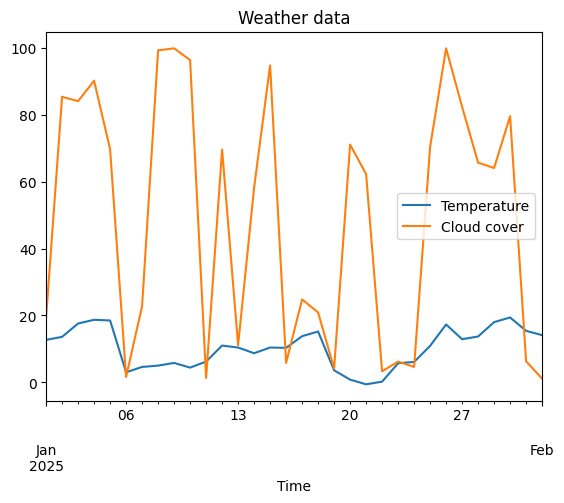

In [15]:
df_temp_clouds.plot(kind='line', title='Weather data', xlabel='Time')

